# Brain MRI Dataset Preparation (KaggleHub)

Goal: download the cleaned 4-class brain tumor MRI dataset from KaggleHub, restructure it into `train/val/test` splits under `data/raw/brain_mri`, and store labels in `labels.json` for each split. Classes: **normal**, **glioma_tumor**, **meningioma_tumor**, **pituitary_tumor**.

Dataset notes (from the authors):

- Images are cleaned (duplicates removed, mislabeled images corrected) and resized to 224×224.
- Three tumor classes plus one normal class; released under CC0.
- Cleaning reduced samples by ~3–9% per class; augmentations (noise, equalization, rotation, flips, brightness) were applied during their preparation.
- Researchers should validate labels with clinical experts before real-world use.


In [1]:
from pathlib import Path
import json
import random
import shutil
from collections import Counter
from typing import Dict, List
import sys

import kagglehub
from tqdm import tqdm

REPO_ROOT = Path.cwd().parents[1]
sys.path.append(str(REPO_ROOT))

RAW_ROOT = REPO_ROOT / 'data' / 'raw'
DATASET_NAME = 'brain_mri'
TARGET_ROOT = RAW_ROOT / DATASET_NAME
SOURCE_ID = 'mohammadhossein77/brain-tumors-dataset'

IMG_EXTS = {'.png', '.jpg', '.jpeg'}
random.seed(42)

print('Repo root:', REPO_ROOT)
print('Target root:', TARGET_ROOT)
print('Kaggle source id:', SOURCE_ID)

Repo root: d:\git projects\certified-attribution-medical-imaging
Target root: d:\git projects\certified-attribution-medical-imaging\data\raw\brain_mri
Kaggle source id: mohammadhossein77/brain-tumors-dataset


## Download and source layout

We pull the dataset via `kagglehub.dataset_download`. The archive expands to directories:

- `Normal/`
- `Tumor/glioma_tumor/`
- `Tumor/meningioma_tumor/`
- `Tumor/pituitary_tumor/`

We will reorganize these into `data/raw/brain_mri/{train,val,test}/images` plus a `labels.json` per split.


In [5]:
source_path = Path(kagglehub.dataset_download(SOURCE_ID))
print('KaggleHub path:', source_path)

# Dataset may be nested under a Data/ directory
base_path = source_path / 'Data' if (source_path / 'Data').exists() else source_path
print('Using base path:', base_path)

source_dirs = {
    'normal': base_path / 'Normal',
    'glioma_tumor': base_path / 'Tumor' / 'glioma_tumor',
    'meningioma_tumor': base_path / 'Tumor' / 'meningioma_tumor',
    'pituitary_tumor': base_path / 'Tumor' / 'pituitary_tumor',
}

def count_images(root: Path) -> int:
    return len([p for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS])

for name, path in source_dirs.items():
    print(f"{name}: {path} -> {count_images(path)} images")

KaggleHub path: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3
Using base path: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3\Data
normal: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3\Data\Normal -> 3066 images
glioma_tumor: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3\Data\Tumor\glioma_tumor -> 6307 images
meningioma_tumor: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3\Data\Tumor\meningioma_tumor -> 6391 images
pituitary_tumor: C:\Users\farih\.cache\kagglehub\datasets\mohammadhossein77\brain-tumors-dataset\versions\3\Data\Tumor\pituitary_tumor -> 5908 images


## Split into train/val/test

We create 70/15/15 splits per class, shuffle deterministically, copy images into split folders, and write `labels.json` (filename → int label). Existing output under `data/raw/brain_mri` is refreshed each run.


In [6]:
SPLIT_FRACS = {'train': 0.7, 'val': 0.15, 'test': 0.15}
LABEL_MAP = {
    'normal': 0,
    'glioma_tumor': 1,
    'meningioma_tumor': 2,
    'pituitary_tumor': 3,
}

def list_images(root: Path) -> List[Path]:
    return [p for p in root.rglob('*') if p.suffix.lower() in IMG_EXTS]

def prepare_splits(source_dirs: Dict[str, Path], target_root: Path, label_map: Dict[str, int], split_fracs: Dict[str, float]):
    if abs(sum(split_fracs.values()) - 1.0) > 1e-6:
        raise ValueError('Split fractions must sum to 1.0')
    if target_root.exists():
        shutil.rmtree(target_root)
    target_root.mkdir(parents=True, exist_ok=True)

    labels: Dict[str, Dict[str, int]] = {s: {} for s in split_fracs}
    stats: Dict[str, Counter] = {s: Counter() for s in split_fracs}
    for split in split_fracs:
        (target_root / split / 'images').mkdir(parents=True, exist_ok=True)

    for class_name, label in label_map.items():
        files = list_images(source_dirs[class_name])
        random.shuffle(files)
        n = len(files)
        n_train = int(n * split_fracs['train'])
        n_val = int(n * split_fracs['val'])
        n_test = n - n_train - n_val
        splits = {
            'train': files[:n_train],
            'val': files[n_train:n_train + n_val],
            'test': files[n_train + n_val:],
        }
        counter = 0
        for split, paths in splits.items():
            for p in paths:
                new_name = f"{class_name}_{counter:05d}{p.suffix.lower()}"
                counter += 1
                dest = target_root / split / 'images' / new_name
                dest.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(p, dest)
                labels[split][new_name] = label
                stats[split][class_name] += 1

    for split, mapping in labels.items():
        with open(target_root / split / 'labels.json', 'w') as f:
            json.dump(mapping, f, indent=2)

    print('Split counts per class:')
    for split, counter in stats.items():
        total = sum(counter.values())
        print(f"  {split}: {dict(counter)} (total={total})")

prepare_splits(source_dirs, TARGET_ROOT, LABEL_MAP, SPLIT_FRACS)

Split counts per class:
  train: {'normal': 2146, 'glioma_tumor': 4414, 'meningioma_tumor': 4473, 'pituitary_tumor': 4135} (total=15168)
  val: {'normal': 459, 'glioma_tumor': 946, 'meningioma_tumor': 958, 'pituitary_tumor': 886} (total=3249)
  test: {'normal': 461, 'glioma_tumor': 947, 'meningioma_tumor': 960, 'pituitary_tumor': 887} (total=3255)


## Verify with `BrainMRIDataset`

A lightweight dataset wrapper mirrors the ISIC/ChestXray loaders. It expects `images/` and `labels.json` under each split in `data/raw/brain_mri`.


In [7]:
from torchvision import transforms
from src.datasets.brain_mri import BrainMRIDataset

tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = BrainMRIDataset(root_dir=str(TARGET_ROOT), split='train', transform=tf)
val_ds = BrainMRIDataset(root_dir=str(TARGET_ROOT), split='val', transform=tf)
test_ds = BrainMRIDataset(root_dir=str(TARGET_ROOT), split='test', transform=tf)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
sample = train_ds[0]
print('Sample keys:', sample.keys())
print('Image shape:', sample['image'].shape, 'Label:', sample['label'])

Dataset sizes: 15168 3249 3255
Sample keys: dict_keys(['image', 'label', 'meta'])
Image shape: torch.Size([3, 224, 224]) Label: 0


## Visualize sample images

Quick sanity check: view a few random training samples with class labels to verify paths and labels look correct.


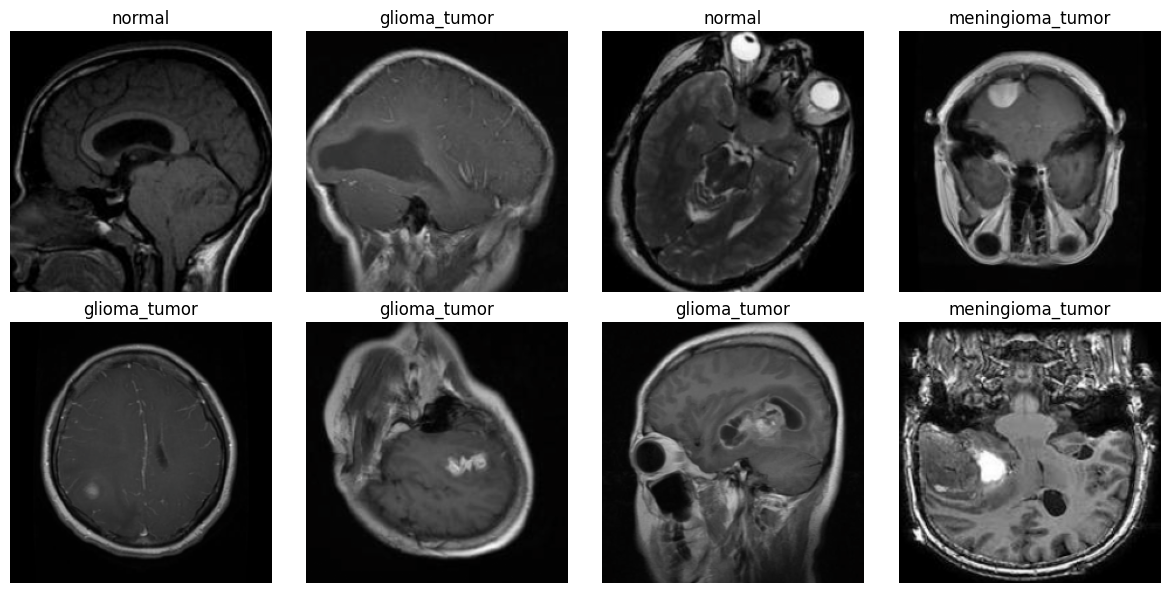

In [8]:
import torch
import matplotlib.pyplot as plt

IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]
class_names = getattr(train_ds, 'classes', ['normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'])

def denorm(img):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * IMG_STD[c] + IMG_MEAN[c]
    return img.clamp(0, 1)

def show_samples(ds, n=8):
    n = min(n, len(ds))
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    indices = torch.randperm(len(ds))[:n]
    for i, idx in enumerate(indices):
        sample = ds[idx]
        img = denorm(sample['image'])
        label = sample['label']
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        title = class_names[label] if label < len(class_names) else str(label)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=8)